In [1]:
!conda env list
!conda create -n DeepMath python="3.10" -y
!/opt/anaconda3/envs/DeepMath/bin/pip install ipykernel
!/opt/anaconda3/envs/DeepMath/bin/python -m ipykernel install --user --name DeepMath
!/opt/anaconda3/envs/DeepMath/bin/pip install pandas numpy scikit-learn matplotlib


# conda environments:
#
# * -> active
# + -> frozen
base                 *   /opt/anaconda3
Deep                     /opt/anaconda3/envs/Deep

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/DeepMath

  added / updated specs:
    - python=3.10


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/osx-arm64::bzip2-1.0.8-h80987f9_6 
  ca-certificates    pkgs/main/osx-arm64::ca-certificates-2026.5.14-hca03da5_0 
  libcxx             pkgs/main/osx-arm64::libcxx-22.1.2-hf894667_0 
  libexpat           pkgs/main/osx-arm64::libexpat-2.8.1-h50f4ffc_0 
  libffi             pkgs/main/osx-arm64::libffi-3.4.8-h4a3ca97_3 
  libzlib            pkgs/m

In [2]:
import pandas as pd
import numpy as np

In [3]:
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url,sep='\s+',skiprows=22,header=None)
data = np.hstack([raw_df.values[::2,:],raw_df.values[1::2,:2]])
target = raw_df.values[1::2,2]
dropnadf = raw_df.dropna(axis=0)
print(dropnadf)

           0     1      2    3      4      5     6       7    8      9     10
0     0.00632  18.0   2.31  0.0  0.538  6.575  65.2  4.0900  1.0  296.0  15.3
2     0.02731   0.0   7.07  0.0  0.469  6.421  78.9  4.9671  2.0  242.0  17.8
4     0.02729   0.0   7.07  0.0  0.469  7.185  61.1  4.9671  2.0  242.0  17.8
6     0.03237   0.0   2.18  0.0  0.458  6.998  45.8  6.0622  3.0  222.0  18.7
8     0.06905   0.0   2.18  0.0  0.458  7.147  54.2  6.0622  3.0  222.0  18.7
...       ...   ...    ...  ...    ...    ...   ...     ...  ...    ...   ...
1002  0.06263   0.0  11.93  0.0  0.573  6.593  69.1  2.4786  1.0  273.0  21.0
1004  0.04527   0.0  11.93  0.0  0.573  6.120  76.7  2.2875  1.0  273.0  21.0
1006  0.06076   0.0  11.93  0.0  0.573  6.976  91.0  2.1675  1.0  273.0  21.0
1008  0.10959   0.0  11.93  0.0  0.573  6.794  89.3  2.3889  1.0  273.0  21.0
1010  0.04741   0.0  11.93  0.0  0.573  6.030  80.8  2.5050  1.0  273.0  21.0

[506 rows x 11 columns]


### 데이터 분류 보고서

data_url에 "https://lib.stat.cmu.edu/datasets/boston"에 있는 데이터를 집어넣고 판다스의 csv읽기 기능을 사용해 데이터를 raw_df로 만들었습니다 그리고 데이터들을 행렬로 연결해서 데이터 변수에 넣었습니다 그리고 타겟에는 raw_df를 슬라이싱했고 dropnadf에 빈공간이있는 데이터 행을 삭제해 꽉꽉채웠습니다

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597 24.90850512 18.63883645
 -6.08842184 21.75834668 19.23922576 26.19319733 20.64773313  5.79472718
 40.50033966 17.61289074 27.24909479 30.06625441 11.34179277 24.16077616
 17.86058499 15.83609765 22.78148106 14.57704449 22.43626052 19.19631835
 22.43383455 25.21979081 25.93909562 17.70162434 16.76911711 16.95125411
 31.23340153 20.13246729 23.76579011 24.6322925  13.94204955 32.25576301
 42.67251161 17.32745046 27.27618614 16.99310991 14.07009109 25.90341861
 20.29485982 29.95339638 21.28860173 34.34451856 16.04739105 26.22562412
 39.53939798 22.57950697 18.84531367 32.72531661 25.0673037  12.88628956
 22.68221908 30.48287757 31.52626806 15.90148607 20.22094826 16.71089812
 20.52384893 25.96356264 30.61607978 11.59783023 20.51232627 27.48111878
 11.01962332 15.68096344 23.79316251  6.19929359 21.6039073  41.41377225
 18.76548695  8.87931901 20.83076916 13.25620627 20

<function matplotlib.pyplot.show(close=None, block=None)>

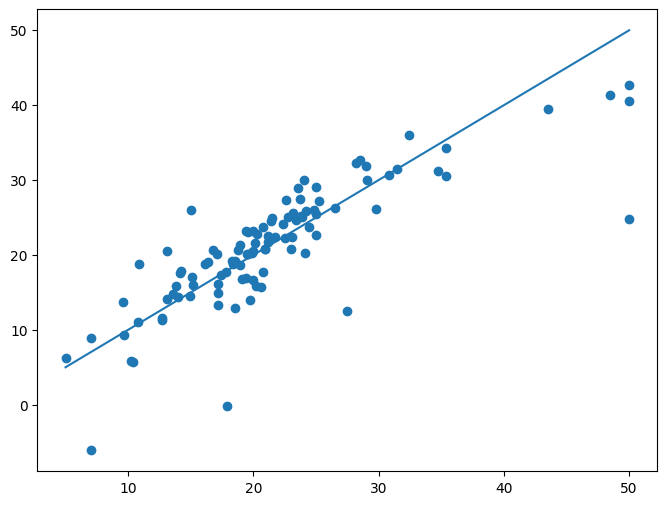

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.DataFrame(data)
df['MEDV'] = target

df = df.dropna(axis=0)

x = df.iloc[:,:13]
y = df['MEDV']


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

y_pred = linear_model.predict(x_test)

residual = y_test - y_pred
print(y_pred)
print(residual)


plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show

### 선형회귀 보고서
df로 데이터를 가져온뒤 train_test_split함수를 사용해 데이터를 분류했습니다 그리고 LinearRegression()을 이용하여 선형 회귀를 구했고 matplotlib를 사용하여 그래프를 그렸습니다


In [5]:
from sklearn.linear_model import LogisticRegression
median_value = df['MEDV'].median()
y = (df['MEDV'] >= median_value).astype(int)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
logistic_model = LogisticRegression(max_iter=10000)
logistic_model.fit(x_train,y_train)

y_pred = logistic_model.predict(x_test)
print(y_pred)

[1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1
 1 0 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0 0
 1 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1]


### 로지스틱회귀 보고서
데이터를 가져온뒤 train_test_split함수를 사용해 데이터를 분류했습니다 그리고 LogisticRegression()을 이용하여 로지스틱 회귀를 구했습니다

In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

y = df['MEDV']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

nn_model = MLPRegressor(hidden_layer_sizes=(64,32),max_iter=2000,random_state=42)

nn_model.fit(x_train_scaler,y_train)
y_pred = nn_model.predict(x_test_scaler)
print(y_pred)

[26.98596669 34.82276033 16.68650975 26.41076325 15.74262016 19.67071607
 15.78365814 13.22895527 24.98263397 17.07352018 21.27187362 17.49468877
  5.5288339  18.19952238 17.82836446 24.74411396 20.60739449  9.63535037
 45.292692   14.05569419 25.101561   25.80326347 13.98339976 22.37721826
 16.59190012 17.32237024 20.83880758 11.48686127 21.36828849 15.74987811
 22.40929188 22.89783763 19.80334615 24.1809273  14.9542994  16.90352717
 31.72380541 20.5053556  22.41623248 25.60127321 13.55245027 28.81443933
 48.17194846 18.33831385 26.16725478 17.36999614 14.86625899 26.91398793
 20.21211999 27.74253537 18.89121892 35.19214961 15.97463661 24.6488837
 42.60023282 22.99024962 16.91871615 30.95835192 25.13673909 15.17652411
 22.36096875 32.73123353 30.82068478 17.03677005 21.83998108 18.27586946
 16.69876093 22.94153998 28.27535121 13.34949843 21.53659549 28.82287156
  8.49194963 22.91914279 20.68898993  5.10846153 20.78527021 45.79516139
 11.83505365 13.53877508 20.44507224 12.56231894 21.

### 뉴럴 네트워크 보고서

데이터를 가져온뒤 train_test_split함수를 사용해 데이터를 분류했습니다 그리고 StandardScaler()을 이용하여 스케일을 조정하고 MLPRegressor()로 인공신경망을 구현했습니다
